# LiteSpecFormer Demo

[LiteSpecFormer](https://huggingface.co/FlowVortex/LiteSpecFormer-1.0-36M) is a lightweight wireless foundation model for **zero-shot confidence spectrum prediction**. It combines a channel-independent Transformer, a sliding autoregressive forecasting paradigm, and quantile outputs so you can forecast arbitrary frequency bands and sequence lengths **without fine-tuning**.

This notebook reproduces the [Quickstart](https://github.com/FlowVortex/LiteSpecFormer#-quickstart) workflow from the README:

| Step | Description |
|------|-------------|
| 1 | Load the pre-trained checkpoint from Hugging Face |
| 2 | Build synthetic multi-channel spectrum-like series with [S2Generator](https://github.com/wwhenxuan/S2Generator) |
| 3 | Run zero-shot forecasting via `LiteSpecFormerPipeline.predict` |
| 4 | Visualize quantile predictions and confidence bands |

**Requirements:** Python 3.11+, `pip install litespecformer`, and `s2generator` for the synthetic data helper.

In [ ]:
# --- Environment setup ---
import os
import sys

import numpy as np
import torch
from matplotlib import pyplot as plt

# Allow importing the local package when running from the repo checkout.
sys.path.append(os.path.abspath("../src"))

# Synthetic spectrum-like series for this demo (same helper as in README Quickstart).
from s2generator.utils import generate_nonstationary_sine

from litespecformer import (
    LiteSpecFormerPipeline,
    plot_confidence_prediction,
)

## 1. Load the Pre-trained Model

We load [LiteSpecFormer-1.0-36M](https://huggingface.co/FlowVortex/LiteSpecFormer-1.0-36M) through `LiteSpecFormerPipeline.from_pretrained`. The pipeline wraps model weights, preprocessing, and autoregressive decoding for inference.

At inference time LiteSpecFormer performs **channel-independent** forecasting: each frequency bin / variate is predicted separately, which enables zero-shot transfer across different spectrum shapes and band counts.

In [2]:
# Download weights from Hugging Face on first run (cached locally afterwards).
pipeline = LiteSpecFormerPipeline.from_pretrained("FlowVortex/LiteSpecFormer-1.0-36M")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/147M [00:00<?, ?B/s]

In [3]:
def count_parameters_human(model):
    """Print total and trainable parameter counts in human-readable units."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"Total parameters: {total / 1e4:.2f}×10⁴ ({total / 1e6:.2f} M)")
    print(f"Trainable parameters: {trainable / 1e4:.2f}×10⁴ ({trainable / 1e6:.2f} M)")

In [4]:
# The released checkpoint is a ~37M-parameter lightweight foundation model.
count_parameters_human(pipeline.model)

Total parameters: 3667.03×10⁴ (36.67 M)
Trainable parameters: 3667.03×10⁴ (36.67 M)


## 2. Prepare Synthetic Input Data

We simulate **5 parallel spectrum channels** with non-stationary sinusoids—standing in for distinct frequency bins or spatial channels. Each series has:

- **`context_length`**: historical observations fed to the model (256 steps here)
- **`prediction_length`**: future horizon to forecast (96 steps here)

In real deployments, replace this block with measured spectrum data (e.g., from [LSPD](https://huggingface.co/datasets/FlowVortex/Large-Spectrum-Prediction-Dataset) or your own CSV / Hugging Face dataset). Input shape should be `(num_channels, context_length)`.

In [5]:
# Context window (look-back) and forecast horizon.
context_length = 256
prediction_length = 96

# Build 5 channel-independent series: shape (num_channels, context_length + prediction_length).
# The trailing `prediction_length` segment is kept as ground truth for visualization only.
time_series = np.vstack(
    [
        generate_nonstationary_sine(
            seq_length=context_length + prediction_length,
            freq=2 + i,  # slightly different frequency per channel
        )
        for i in range(5)
    ]
)

time_series.shape

(5, 352)

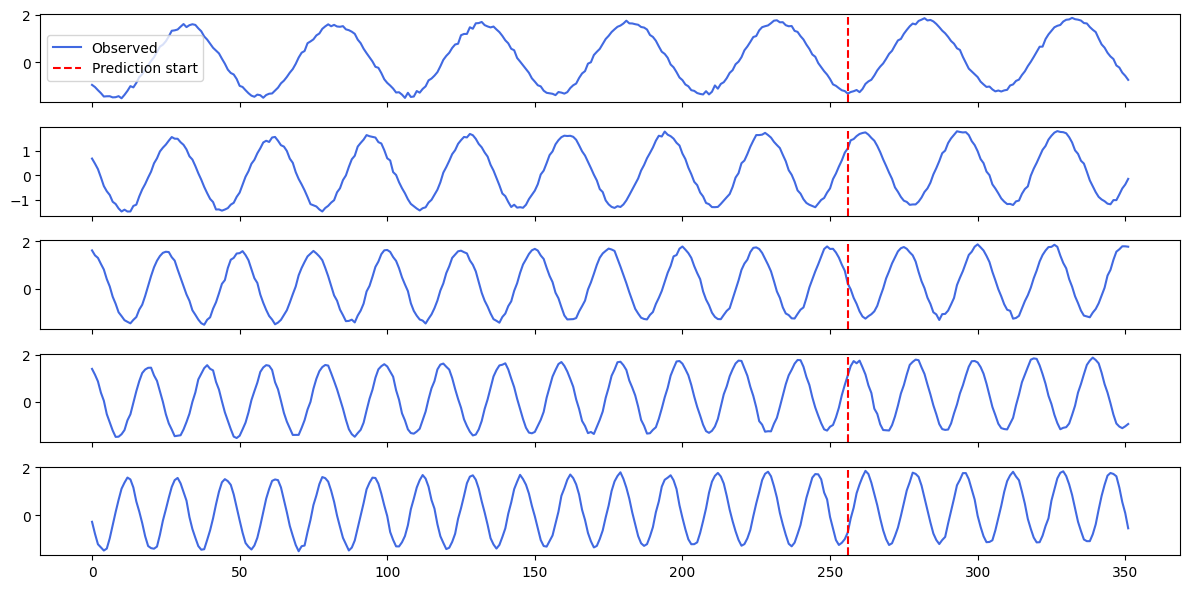

In [6]:
# Visualize each channel: blue = observed context, red dashed line = forecast start.
fig, ax = plt.subplots(5, 1, figsize=(12, 6), sharex=True)

for i in range(5):
    ax[i].plot(time_series[i], label="Observed", color="royalblue")
    ax[i].axvline(
        x=context_length,
        color="r",
        linestyle="--",
        label="Prediction start",
    )

    if i == 0:
        ax[i].legend()

plt.tight_layout()

## 3. Zero-Shot Prediction

Call `pipeline.predict` with shape `(num_channels, context_length)`. LiteSpecFormer autoregressively rolls out `prediction_length` future steps and returns **quantile forecasts** (confidence spectrum prediction).

See the README for full workflows: [pre-training](https://github.com/FlowVortex/LiteSpecFormer#model-pre-train-and-fine-tune), [fine-tuning](https://github.com/FlowVortex/LiteSpecFormer#model-pre-train-and-fine-tune), and [zero-shot evaluation scripts](https://github.com/FlowVortex/LiteSpecFormer#zero-shot-evaluation).

In [7]:
# Convert to torch.Tensor — pipeline accepts NumP|y or PyTorch inputs.
time_series = torch.from_numpy(time_series)

time_series.shape

torch.Size([5, 352])

In [8]:
# Zero-shot forecast: pass only the context window; no fine-tuning required.
# Returns a list of quantile tensors, one per input channel.
outputs = pipeline.predict(
    time_series[:, :context_length],
    prediction_length=prediction_length,
)

# Shape: (num_quantiles, prediction_length) for the first channel
outputs[0].shape

torch.Size([11, 96])

## 4. Visualize Confidence Predictions

`plot_confidence_prediction` overlays the context, optional ground-truth future segment, median quantile, and shaded confidence intervals—matching the visualization style used in our [benchmark results](https://github.com/FlowVortex/LiteSpecFormer#forecasting-visualization).

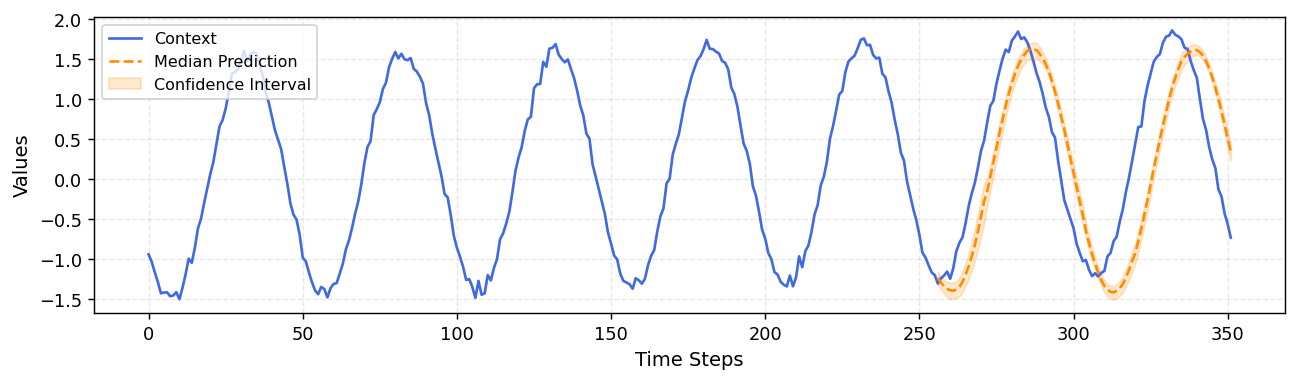

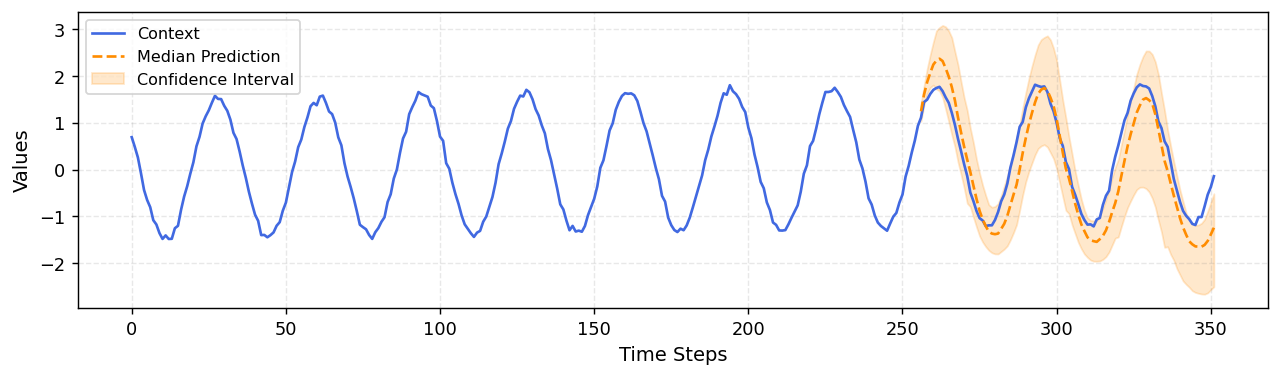

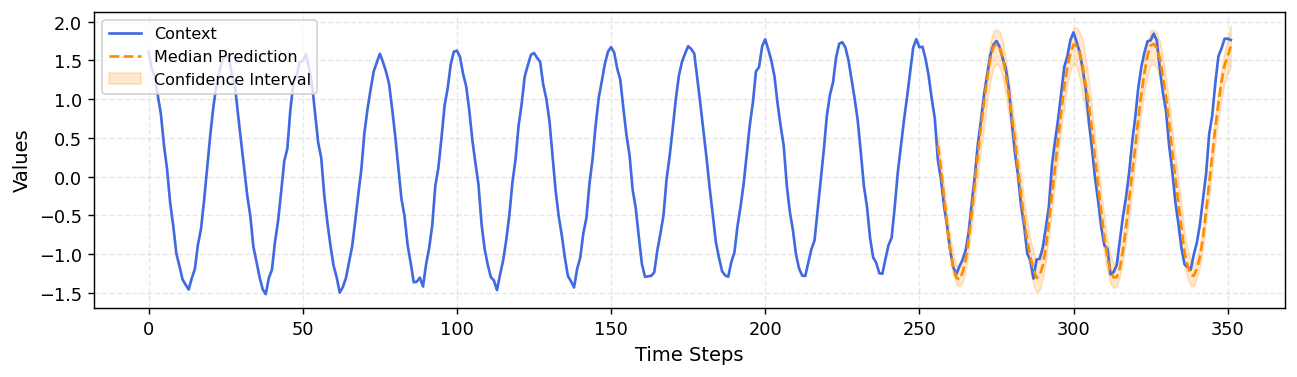

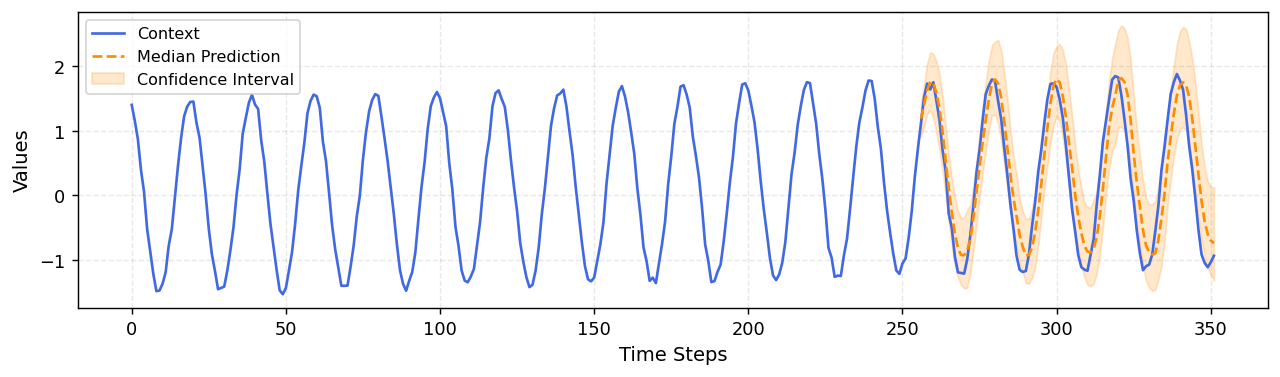

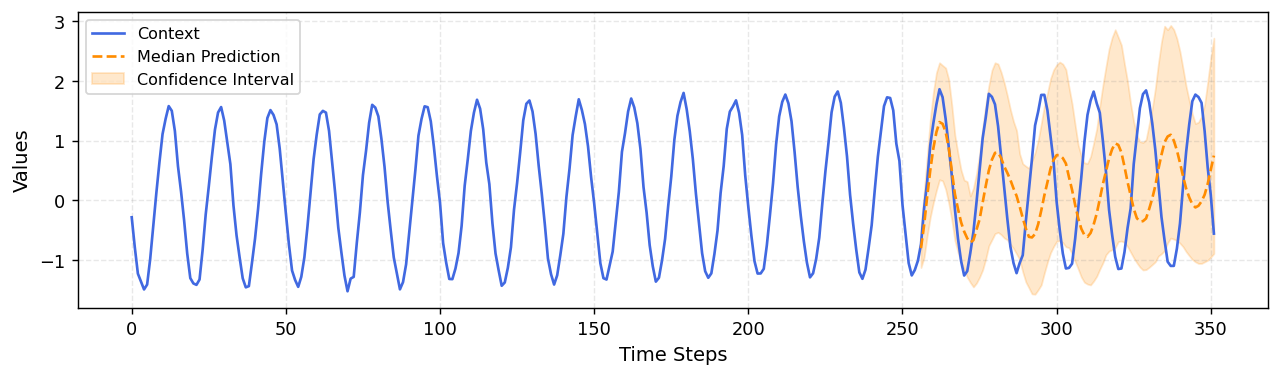

In [9]:
# Plot median forecast and confidence bands for each channel.
# `target` is optional here and only used for comparing against ground truth in this synthetic demo.
for i in range(5):
    fig = plot_confidence_prediction(
        context=time_series[i, :context_length].numpy(),
        prediction=outputs[i].numpy(),
        target=time_series[
            i, context_length : context_length + prediction_length
        ].numpy(),
        median_quantile_index=5,
    )

## 5. Inspect Patch Embeddings (Optional)

The encoder maps each context window into patch-level embeddings. This is helpful for debugging, feature analysis, or building downstream heads on top of the foundation model.

In [10]:
# Optional: inspect patch embeddings produced by the input encoder.
# Useful for representation analysis or downstream probing tasks.
pipeline.embed(time_series[:, :context_length])

([tensor([[[ 9.3390e-03, -9.6502e-02, -7.4244e-02,  ..., -2.5261e-01,
            -1.0682e-01, -2.7525e-02],
           [ 2.2586e-02,  1.2908e-01, -2.1232e-01,  ..., -9.9840e-02,
             1.0351e-01,  5.2578e-02],
           [-1.7102e-02,  8.6494e-02, -1.1926e-01,  ...,  1.1090e-01,
            -4.2908e-02,  1.4034e-01],
           ...,
           [ 1.1371e-02, -1.0015e-01, -1.7773e-02,  ..., -1.8235e-02,
            -7.9666e-02, -2.3253e-02],
           [-2.2009e-02,  4.0383e-02, -1.7057e-01,  ..., -3.0451e-02,
             1.1512e-01,  3.4828e-02],
           [ 4.0911e-02,  2.0803e-02,  3.4911e-02,  ...,  3.1819e-02,
             5.9001e-02,  4.0880e-02]],
  
          [[ 1.3281e-01,  1.9819e-01, -7.7383e-02,  ..., -1.0688e-01,
            -1.6858e-01, -1.2387e-01],
           [-1.2500e-01, -4.4716e-02,  1.1842e-01,  ..., -1.0330e-01,
             8.5704e-04,  7.9703e-02],
           [ 2.2183e-02,  5.1892e-02,  1.8288e-02,  ..., -9.2101e-03,
            -1.5944e-01,  7.7002e-02],